<h3> Method with Attention-pooled mean the centeroid embedding of a document and Hierachical clustering. </h3>

<h5> Imports </h5>

In [1]:
import json
import glob
import os

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from kneed import KneeLocator

import shutil

<h5> To avoid the re-embedding from scratch, we just pick-up the embedding results from the files </h5>

In [ ]:
# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
files_dir = "data"
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Total documents loaded: {len(all_results)}")

<h5> Compute an Attention-pooled mean from individual chunks (page embeddings) for each document </h5>

In [3]:
import numpy as np

def doc_vector_attention_pool(page_embeddings, alpha=5.0, iters=3):
    """
    Attention-like pooling: pages closer to the center get higher weight.
    page_embeddings: List[np.ndarray] (L2-normalized)
    alpha: sharpness of attention (5–10 works well)
    iters: refinement steps
    """
    if not page_embeddings:
        return None
    
    V = np.vstack(page_embeddings).astype("float32")  # (n,d)
    if len(V) == 1:
        return V[0]

    # start with simple mean
    c = V.mean(axis=0)
    c /= (np.linalg.norm(c) + 1e-12)

    for _ in range(iters):
        sims = V @ c  # cosine, since everything is normalized
        w = np.exp(alpha * sims)
        w /= (w.sum() + 1e-12)
        c = (w[:, None] * V).sum(axis=0)
        c /= (np.linalg.norm(c) + 1e-12)

    return c

In [4]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = doc_vector_attention_pool(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()

In [ ]:
import umap

X_array = np.array([doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None])
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X_array)

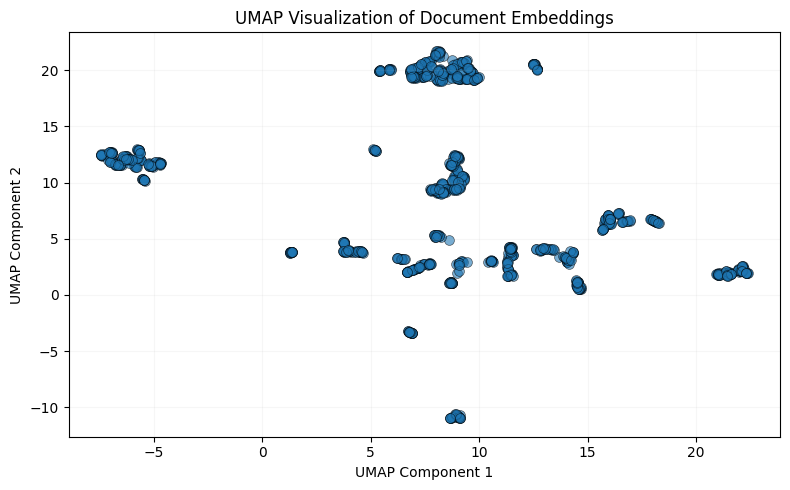

Visualized 1064 documents in 2D space
UMAP reduced dimensions from 3072 to 2


In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title("UMAP Visualization of Document Embeddings")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

print(f"Visualized {len(X_2d)} documents in 2D space")
print(f"UMAP reduced dimensions from {X_array.shape[1]} to {X_2d.shape[1]}")

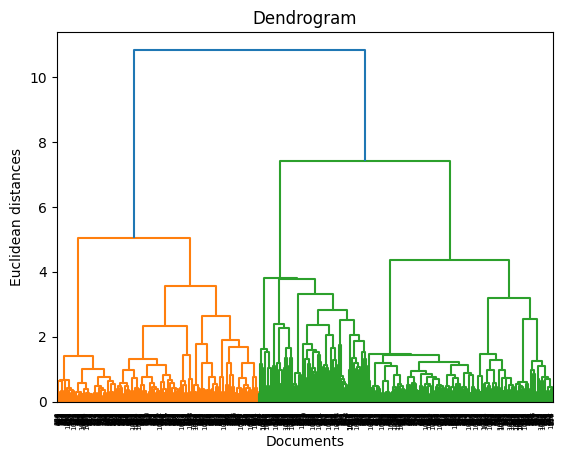

In [7]:
# Using dendrogram to find the optimal number of clusters
# We use the scipy library to create the dendrogram
# pip install scipy
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage([doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None], method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Documents')
plt.ylabel('Euclidean distances')
plt.show()

In [8]:
n_clusters = 3

In [9]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
X = [doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None]
y_hc = hc.fit_predict(X)

In [ ]:
# Add cluster labels to all_results
cluster_idx = 0
for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc['cluster'] = int(y_hc[cluster_idx])
        cluster_idx += 1

# Display clustering results
print(f"Clustering complete with {n_clusters} clusters")
print("\nCluster distribution:")
for i in range(n_clusters):
    count = np.sum(y_hc == i)
    print(f"Cluster {i}: {count} documents")

# Show sample documents from each cluster
print("\nSample documents per cluster:")
for i in range(n_clusters):
    cluster_docs = [os.path.basename(doc['file']) for doc in all_results 
                   if doc.get('doc_vector') is not None and doc.get('cluster') == i]
    print(f"\nCluster {i} ({len(cluster_docs)} docs):")
    # Show first 5 documents
    for doc in cluster_docs[:5]:
        print(f"  - {doc}")
    if len(cluster_docs) > 5:
        print(f"  ... and {len(cluster_docs) - 5} more")

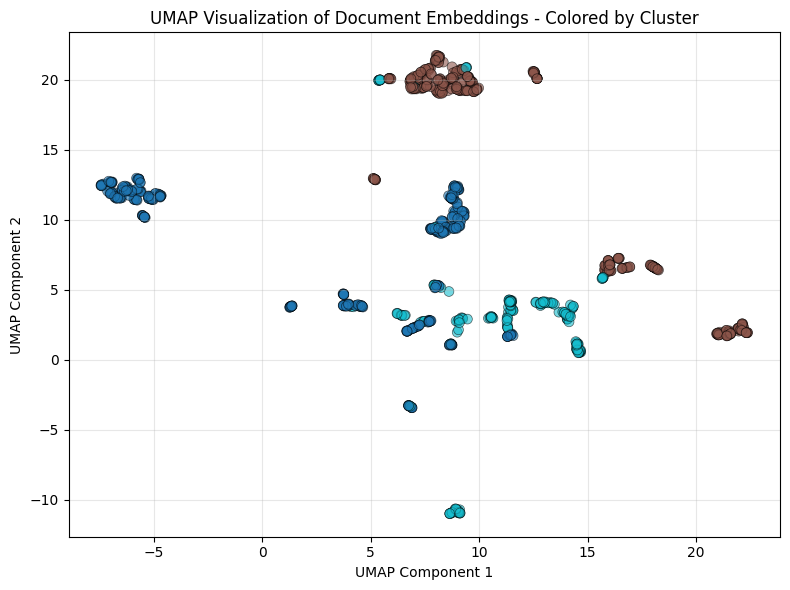


Cluster distribution in the visualization:
Cluster 0: 434 documents
Cluster 1: 398 documents
Cluster 2: 232 documents


In [11]:
# Visualize clusters using UMAP with different colors for each cluster
plt.figure(figsize=(8, 6))

# Get cluster labels for documents with vectors
cluster_labels_for_plot = []
for doc in all_results:
    if doc.get('doc_vector') is not None:
        cluster_labels_for_plot.append(doc.get('cluster', -1))

# Create scatter plot with different colors for each cluster
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels_for_plot, 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.title("UMAP Visualization of Document Embeddings - Colored by Cluster")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print cluster distribution
print("\nCluster distribution in the visualization:")
unique_clusters, counts = np.unique(cluster_labels_for_plot, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    print(f"Cluster {cluster_id}: {count} documents")

In [ ]:
# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters-10")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename for destination
            original_filename = os.path.basename(doc['file'])
            
            # Source file path (use the full path from doc['file'])
            source_file = doc['file']
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, original_filename)
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
            else:
                print(f"Warning: File not found: {source_file}")
    
    print(f"Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"All files organized into {clusters_main_dir}")